# Link Prediction mit GINE

Gleiche Daten, gleicher Trainingsloop und gleicher Decoder wie in `GATV2.ipynb`, nur der
Message-Passing-Teil wird durch `GINEConv` ersetzt. Dadurch ist der Vergleich der beiden
Architekturen fair.

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gnn_pipeline import load_bundle, train_link_predictor, evaluate_link_predictor, plot_auc_history

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

bundle = load_bundle(device=device)   # processed/philadelphia_split.pt
data, train_data, val_data, test_data = bundle.data, bundle.train, bundle.val, bundle.test

in_channels = data.x.size(1)
edge_dim = data.edge_attr.size(1)

C:\Users\gurke\PycharmProjects\Guericke_GNN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\gurke\PycharmProjects\Guericke_GNN\.venv\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Device: cpu
Split geladen: processed\philadelphia_split.pt
Knoten: 13389, Kanten: 40003
Knotenfeatures (2): ['x', 'y']
Kantenfeatures (17): ['Capacity', 'Length', 'free_flow_time', 'Toll', 'capacity_ratio', 'delta_x', 'delta_y', 'capacity_is_placeholder', 'has_reciprocal', 'link_type_1', 'link_type_2', 'link_type_3', 'link_type_4', 'link_type_6', 'link_type_7', 'link_type_8', 'link_type_9']
train: msg-passing Kanten=32003, Label-Paare pos=32003 neg=64006
val: msg-passing Kanten=32003, Label-Paare pos=4000 neg=8000
test: msg-passing Kanten=36003, Label-Paare pos=4000 neg=8000
meta: {'seed': 42, 'val_ratio': 0.1, 'test_ratio': 0.1, 'neg_sampling_ratio': 2.0, 'node_features': ['coords']}


## Graph Isomorphism Network mit Kantenfeatures (GINE)

GIN aggregiert Nachbarn per **Summe** und wendet dann ein MLP an – das ist so ausdrucksstark wie
der Weisfeiler-Lehman-Test. GINE (Hu et al., *Strategies for Pre-training GNNs*) erweitert dies um
Kantenfeatures:

$$x_i' = \mathrm{MLP}\Big((1+\epsilon)\, x_i + \sum_{j \in \mathcal{N}(i)} \mathrm{ReLU}(x_j + W_e\, e_{ji})\Big)$$

Über `edge_dim` projiziert `GINEConv` die Kantenfeatures linear auf die Knotendimension, damit
die Addition $x_j + W_e e_{ji}$ möglich ist.

**Unterschiede zu GATv2, die für die Interpretation wichtig sind:**
- keine Attention, alle Nachbarn zählen gleich (gewichtet nur durch die Kantenfeatures),
- Summen-Aggregation macht GINE sensibel für den Knotengrad – bei nur `x, y` als Knotenfeature
  ist das Eingangssignal dünn; `node_features=["coords", "node_type", "degree"]` in
  `data_prep.ipynb` ist ein naheliegendes Experiment,
- `BatchNorm` zwischen den Schichten stabilisiert die Summen.

In [2]:
import torch.nn as nn
from torch_geometric.nn import GINEConv

def _mlp(in_dim, out_dim):
    return nn.Sequential(
        nn.Linear(in_dim, out_dim),
        nn.BatchNorm1d(out_dim),
        nn.ReLU(),
        nn.Linear(out_dim, out_dim),
    )

class GINELinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_dim, dropout=0.3, train_eps=True):
        super().__init__()
        # Eingangsprojektion, damit die erste Schicht bereits in hidden_channels rechnet
        self.lin_in = nn.Linear(in_channels, hidden_channels)
        self.conv1 = GINEConv(_mlp(hidden_channels, hidden_channels), train_eps=train_eps, edge_dim=edge_dim)
        self.conv2 = GINEConv(_mlp(hidden_channels, hidden_channels), train_eps=train_eps, edge_dim=edge_dim)
        self.conv3 = GINEConv(_mlp(hidden_channels, out_channels), train_eps=train_eps, edge_dim=edge_dim)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.dropout = nn.Dropout(dropout)
        # identischer Decoder wie beim GATv2-Modell
        self.decoder = nn.Sequential(
            nn.Linear(out_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1),
        )

    def forward(self, x, edge_index, edge_attr):
        x = self.lin_in(x).relu()
        x = self.dropout(self.bn1(self.conv1(x, edge_index, edge_attr)).relu())
        x = self.dropout(self.bn2(self.conv2(x, edge_index, edge_attr)).relu())
        return self.conv3(x, edge_index, edge_attr)

    def predict_link(self, node_embeddings, edge_label_index):
        src, dst = node_embeddings[edge_label_index[0]], node_embeddings[edge_label_index[1]]
        return self.decoder(torch.cat([src, dst], dim=1)).squeeze(-1)

In [3]:
MODEL_NAME = "GINE"
HIDDEN, OUT = 128, 256
EPOCHS, LR, WEIGHT_DECAY = 200, 0.01, 0.0

torch.manual_seed(bundle.meta.get("seed", 42))
model = GINELinkPredictor(in_channels, HIDDEN, OUT, edge_dim).to(device)
print(model)
print(f"Parameter: {sum(p.numel() for p in model.parameters()):,}")

GINELinkPredictor(
  (lin_in): Linear(in_features=2, out_features=128, bias=True)
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv3): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
  ))
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, 

Epoch 001 | train loss 0.6862 | val AUC 0.5438 | test AUC 0.5371
Epoch 010 | train loss 0.6803 | val AUC 0.4982 | test AUC 0.5124
Epoch 020 | train loss 0.6612 | val AUC 0.5197 | test AUC 0.5203
Epoch 030 | train loss 0.6473 | val AUC 0.4796 | test AUC 0.4850
Epoch 040 | train loss 0.6340 | val AUC 0.4394 | test AUC 0.4558
Epoch 050 | train loss 0.6292 | val AUC 0.4277 | test AUC 0.4420
Epoch 060 | train loss 0.6251 | val AUC 0.4970 | test AUC 0.5007
Epoch 070 | train loss 0.6231 | val AUC 0.4952 | test AUC 0.4985
Epoch 080 | train loss 0.6368 | val AUC 0.5085 | test AUC 0.5059
Epoch 090 | train loss 0.6212 | val AUC 0.4904 | test AUC 0.4937
Epoch 100 | train loss 0.6202 | val AUC 0.4968 | test AUC 0.4999
Epoch 110 | train loss 0.6198 | val AUC 0.4924 | test AUC 0.4965
Epoch 120 | train loss 0.6185 | val AUC 0.4867 | test AUC 0.4900
Epoch 130 | train loss 0.6181 | val AUC 0.5028 | test AUC 0.5080
Epoch 140 | train loss 0.6179 | val AUC 0.4975 | test AUC 0.5022
Epoch 150 | train loss 0.

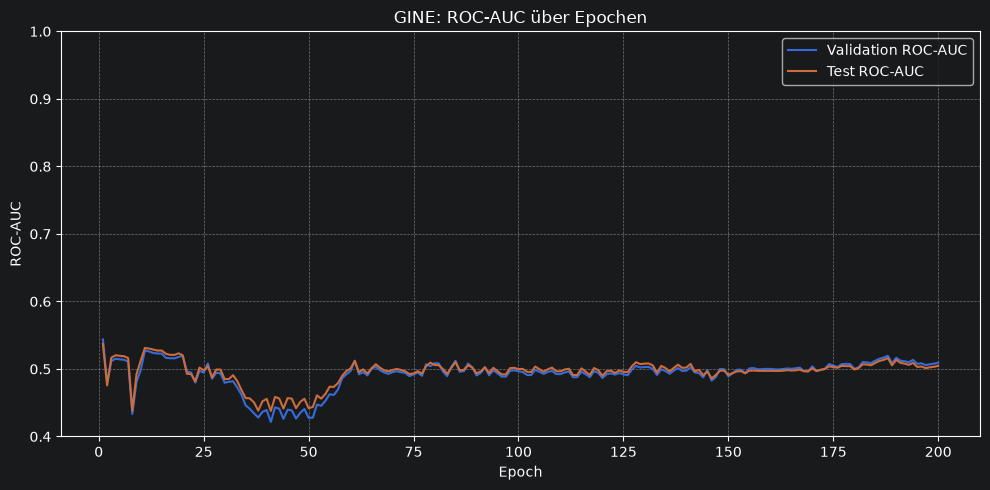

Finale Test-Loss 0.6620 | Test-ROC-AUC 0.5047


In [4]:
history = train_link_predictor(
    model, train_data, val_data, test_data,
    epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, log_every=10,
)
plot_auc_history(history, title=f'{MODEL_NAME}: ROC-AUC über Epochen')
plt.show()

test_loss, test_auc = evaluate_link_predictor(model, train_data, test_data)
print(f"Finale Test-Loss {test_loss:.4f} | Test-ROC-AUC {test_auc:.4f}")

## Visualisierung der Knoten-Embeddings

PCA der gelernten Embeddings auf 2 Dimensionen, eingefärbt nach Knotentyp (Zone / Kreuzung).

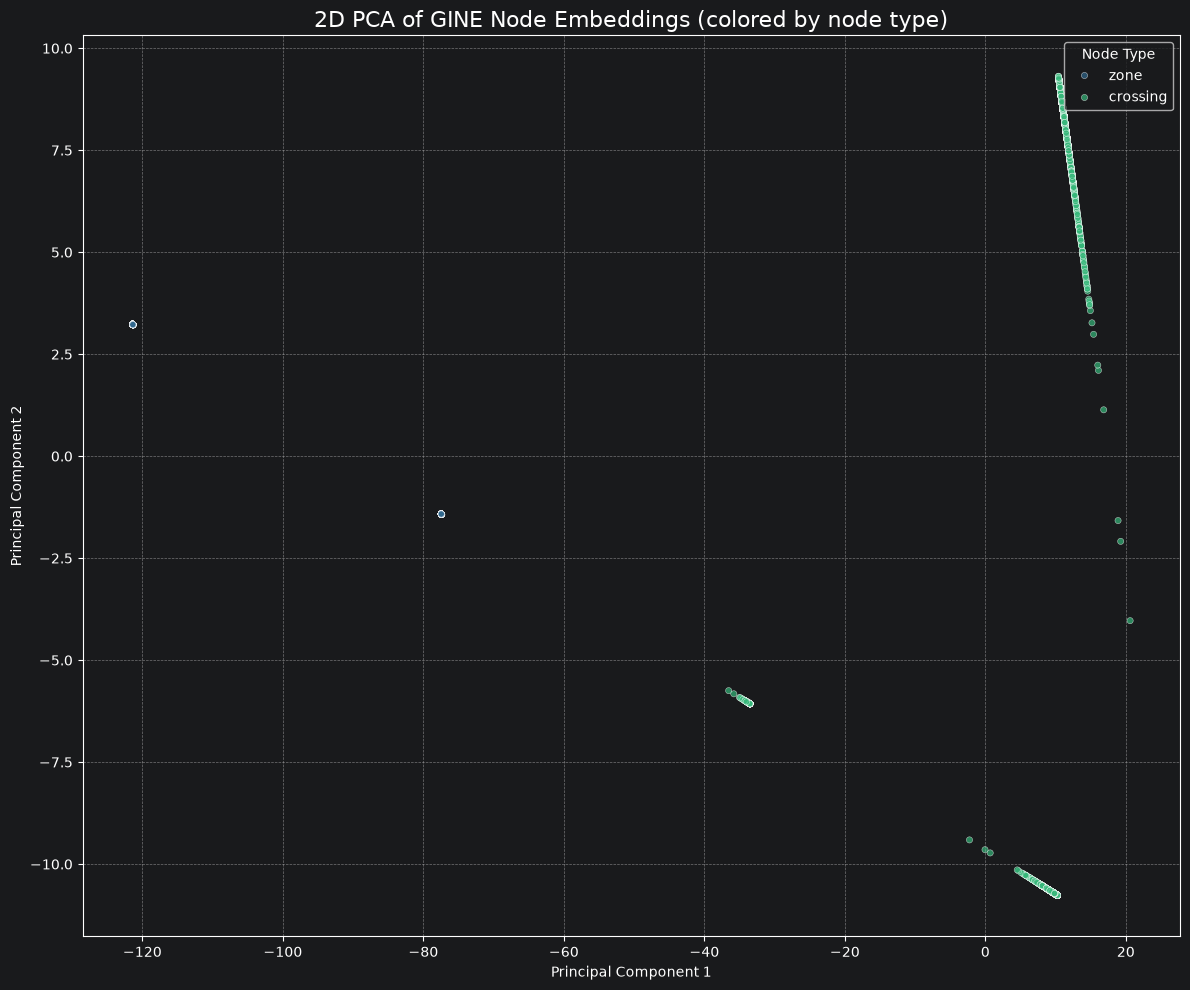

In [5]:
from sklearn.decomposition import PCA

model.eval()
with torch.no_grad():
    emb = model(data.x, data.edge_index, data.edge_attr).cpu().numpy()

emb_2d = PCA(n_components=2).fit_transform(emb)
plot_df = pd.DataFrame({'component_1': emb_2d[:, 0], 'component_2': emb_2d[:, 1], 'node_type': bundle.node_type})

plt.figure(figsize=(12, 10))
sns.scatterplot(data=plot_df, x='component_1', y='component_2', hue='node_type', palette='viridis', alpha=0.7, s=20)
plt.title(f'2D PCA of {MODEL_NAME} Node Embeddings (colored by node type)', size=16)
plt.xlabel('Principal Component 1'); plt.ylabel('Principal Component 2')
plt.legend(title='Node Type'); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout()
plt.show()

## Feature-Analyse: Korrelation der Kantenfeatures mit dem Label

Pearson-Korrelation jedes Kantenfeatures (aus `edge_label_attr`) mit `edge_label` im Trainingssplit.
Hinweis: Negative Beispiele tragen zufällig gezogene Features, daher sind hohe Korrelationen hier nicht zu erwarten.

capacity_ratio             0.004903
link_type_2                0.003505
link_type_9                0.003117
capacity_is_placeholder    0.002226
Capacity                   0.002199
link_type_7                0.001366
link_type_3                0.000517
link_type_8                0.000463
has_reciprocal             0.000367
Toll                       0.000309
delta_y                   -0.000712
Length                    -0.000947
link_type_4               -0.000988
delta_x                   -0.001034
link_type_6               -0.001787
link_type_1               -0.002341
free_flow_time            -0.002536
Name: edge_label, dtype: float64


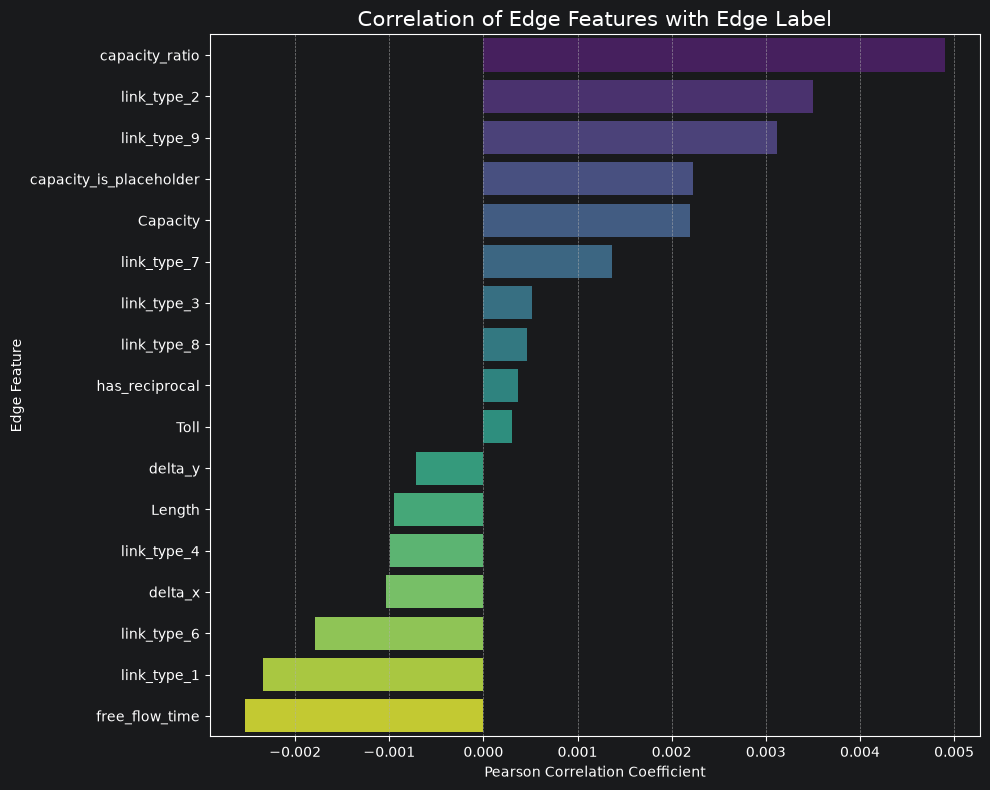

In [6]:
features_df = pd.DataFrame(train_data.edge_label_attr.cpu().numpy(), columns=bundle.edge_attr_columns)
features_df['edge_label'] = train_data.edge_label.cpu().numpy()
corr = features_df.corr()['edge_label'].drop('edge_label').sort_values(ascending=False)
print(corr)

plt.figure(figsize=(10, 8))
sns.barplot(x=corr.values, y=corr.index, hue=corr.index, palette='viridis', legend=False)
plt.title('Correlation of Edge Features with Edge Label', size=15)
plt.xlabel('Pearson Correlation Coefficient'); plt.ylabel('Edge Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7); plt.tight_layout()
plt.show()